# Optimisation functions

In [30]:
import datetime as dt
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import subprocess 
import sqlite3
import scipy.optimize 
from skopt import gp_minimize
from skopt.callbacks import CheckpointSaver
from skopt import load
from skopt.plots import plot_convergence
from skopt.space import Real
from skopt.space import Space
from skopt import Optimizer
from skopt.utils import create_result
import matplotlib.gridspec as gridspec
import os
from pathlib import Path

%matplotlib inline

def calcLoss(fitting_variables, obs_pred):
    """
    Calculate loss using NSE with:
    - Strict validation (fatal on structural issues)
    - Smooth squashing for poor NSE
    - Full resolution for good NSE
    """

    sc_obs = []
    sc_pred = []

    # -------------------------
    # Extract and scale data
    # -------------------------
    for var in fitting_variables:
        obs_col = f"Observed.{var}"
        pred_col = f"Predicted.{var}"

        if obs_col not in obs_pred or pred_col not in obs_pred:
            print(f"⚠️ Skipping variable '{var}' (missing columns)")
            continue
        
        df = obs_pred[[obs_col, pred_col]].dropna()

        if df.empty:
            print(f"No valid data for variable '{var}' after dropping NaNs")
            continue

        # Ensure numeric
        df[obs_col] = pd.to_numeric(df[obs_col], errors="coerce")
        df[pred_col] = pd.to_numeric(df[pred_col], errors="coerce")

        df = df.dropna()

        if df.empty:
            raise RuntimeError(
                f"No valid numeric data for variable '{var}'"
            )

        v_max = df[obs_col].max()
        v_min = df[obs_col].min()

        # -------------------------
        # Scaling safety (should not happen now)
        # -------------------------
        if v_max == v_min:
            raise RuntimeError(
                f"Zero variation in observations for '{var}'. "
                "This indicates a data or simulation issue."
            )

        # Scale to 0–1
        obs_scaled = (df[obs_col] - v_min) / (v_max - v_min)
        pred_scaled = (df[pred_col] - v_min) / (v_max - v_min)

        sc_obs.append(obs_scaled.values)
        sc_pred.append(pred_scaled.values)

    # -------------------------
    # Final concatenation
    # -------------------------
    if not sc_obs:
        raise RuntimeError(
            "No valid observation/prediction data found across all variables."
        )

    sc_obs = np.concatenate(sc_obs)
    sc_pred = np.concatenate(sc_pred)

    # -------------------------
    # NSE calculation
    # -------------------------
    obs_mean = np.mean(sc_obs)
    denominator = np.sum((sc_obs - obs_mean) ** 2)

    if denominator == 0:
        raise RuntimeError(
            "Zero variance in observations (NSE undefined). "
            "Check simulation outputs."
        )

    nse = 1.0 - np.sum((sc_obs - sc_pred) ** 2) / denominator

    # -------------------------
    # LOSS TRANSFORMATION
    # -------------------------
    # Keep full resolution for good fits
    if nse >= 0:
        loss = -nse
    else:
        # Smooth squash for poor fits (no hard cap)
        loss = np.tanh(-nse)

    return loss, len(sc_obs), sc_obs, sc_pred

class ResultsStore:
    def __init__(self):
        self.records = []
        self.iteration = 0

    def addResult(
        self,
        cultivar,
        parameters,
        loss,
        nObs,
        runtime=None,
        obs=None,
        pred=None,
        variable=None,
    ):
        """
        Store results from one APSIM evaluation.

        obs, pred: array-like (NumPy arrays or lists)
        variable: name of fitted variable (optional)
        """
        self.iteration += 1

        record = {
            "iteration": self.iteration,
            "cultivar": cultivar,
            "loss": loss,
            "n_obs": nObs,
            "runtime": runtime,
            "variable": variable,
            **{f"param_{k}": v for k, v in parameters.items()}
        }

        # Store arrays as-is (NumPy arrays are fine)
        record["obs"] = obs
        record["pred"] = pred

        self.records.append(record)

    def to_dataframe(self, drop_arrays=False):
        """
        Convert to DataFrame. Optionally drop obs/pred arrays.
        """
        if drop_arrays:
            return pd.DataFrame([
                {k: v for k, v in r.items() if k not in ("obs", "pred")}
                for r in self.records
            ])
        return pd.DataFrame(self.records)

def runModelGetStats(runSpec, paramSet, fittingVariables):

    apsimx = os.path.join(runSpec["simulationPath"], f"{runSpec['apsimFileName']}.apsimx")
    apply  = os.path.join(runSpec["simulationPath"], f"tempApplyCLI.txt")
    
    db = os.path.join(runSpec["simulationPath"], f"{runSpec['apsimFileName']}.db")
    db_path = Path(db)

    # Ensure clean DB
    if db_path.exists():
        db_path.unlink()

    # Write apply file
    write_cultivar_apply_file(apply_path=Path(apply),apsimx_path=Path(apsimx),cultivar_name=runSpec["cultivarName"],
        parameters=paramSet,playListName="tempChooseCultivar")

    start = dt.datetime.now()

    # -----------------------------
    # RUN APSIM (main run)
    # -----------------------------
    result = subprocess.run(
        [
            APSIM_EXE,
            apsimx,
            "--apply", apply,
            "--playlist", "tempChooseCultivar"
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=300
    )

    output = result.stdout or ""

    # --- Detect NO MATCH case ---
    if "Playlist was used but no simulations or experiments match the contents of the list" in output:
        print(f"⚠️ No matching simulations for {runSpec['apsimFileName']} (skipping)")

        # cleanup before exit
        remove_cultivar_apply_file(apply_path=Path(apply),apsimx_path=Path(apsimx),
            cultivar_name=runSpec["cultivarName"],playListName="tempChooseCultivar")

        subprocess.run(
            [APSIM_EXE, apsimx, "--apply", apply],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )

        endrun = dt.datetime.now()
        runtime = (endrun - start).seconds

        return pd.DataFrame(), runtime

    # --- Print only meaningful output ---
    if output.strip():
        print(output)

    #-----------------------------
    #CLEANUP (remove temp nodes)
    #-----------------------------
    remove_cultivar_apply_file(
        apply_path=Path(apply),
        apsimx_path=Path(apsimx),
        cultivar_name=runSpec["cultivarName"],
        playListName="tempChooseCultivar"
    )

    result = subprocess.run(
        [
            APSIM_EXE,
            apsimx,
            "--apply", apply
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    if result.stdout and result.stdout.strip():
        print(result.stdout)

    endrun = dt.datetime.now()
    runtime = (endrun - start).seconds

    # -----------------------------
    # SAFE DB READ
    # -----------------------------
    if not os.path.exists(db):
        print(f"⚠️ DB not created for {runSpec['apsimFileName']} (skipping)")
        return pd.DataFrame(), runtime

    con = sqlite3.connect(db)

    try:
        tables = pd.read_sql(
            "SELECT name FROM sqlite_master WHERE type='table';",
            con
        )["name"].tolist()

        if runSpec['reportName'] not in tables:
            print(f"⚠️ Table {runSpec['reportName']} missing in {runSpec['apsimFileName']} (skipping)")
            return pd.DataFrame(), runtime

        obs_pred = pd.read_sql(f"SELECT * FROM {runSpec['reportName']}", con)

    finally:
        con.close()

    return obs_pred, runtime

def runModelItter(runSpecs, paramSet, fittingVariables, resultsStore=None, printResult=False):
    """
    Run one parameter set across all APSIM files listed in runSpecs and merge results.
    """

    allObsPred = []
    totalRuntime = 0
    itter = 0

    for runSpec in runSpecs:
        obsPred, runtime = runModelGetStats(
            runSpec=runSpec,
            paramSet=paramSet,
            fittingVariables=fittingVariables
        )

        if not obsPred.empty:
            allObsPred.append(obsPred)

        totalRuntime += runtime

        
    if len(allObsPred) == 0:
        print("❌ No valid simulations produced data")
        return 2.0

    obsPredAll = pd.concat(allObsPred, ignore_index=True)

    # Compute loss and scaled values
    loss, nObs, scObs, scPred = calcLoss(fittingVariables, obsPredAll)

    # Optional: store results
    if resultsStore is not None:
        resultsStore.addResult(
            cultivar=runSpecs[0]["cultivarName"],
            parameters=paramSet,
            loss=loss,
            nObs=nObs,
            runtime=totalRuntime,
            obs=scObs,
            pred=scPred
        )
        
        itter = resultsStore.iteration

    if printResult:
        print(
            f"[{itter:03d}] | "
            f"{list(paramSet.values())} run completed | "
            f"{nObs} obs in {totalRuntime} seconds. | "
            f"NSE = {-loss:.3f}"
        )

    return loss

# ------------------------------------------------------------
# Stagnation detection helpers
# ------------------------------------------------------------

def stagnation_detected(res, window=5, eps=None):
    """
    Detect whether the optimiser has stopped moving in parameter space.
    """
    if len(res.x_iters) < window + 1:
        return False

    recent_moves = np.linalg.norm(
        np.diff(np.array(res.x_iters[-window:]), axis=0),
        axis=1
    )

    return np.max(recent_moves) < eps


def loss_stagnated(res, window=10, tol=0.02):
    """
    Detect whether loss improvement has stalled.
    """
    if len(res.func_vals) < window:
        return False

    y_hist = np.array(res.func_vals)

    best = np.minimum.accumulate(y_hist)
    recent = best[-window:]

    return (recent[0] - recent[-1]) < tol

def format_param(val, p):
    step = p.get("step", None)

    if step is None:
        return f"{val:.3f}"

    # determine decimals from step size
    decimals = max(0, int(-np.log10(step))) if step < 1 else 0

    if decimals == 0:
        return f"{int(round(val))}"
    else:
        return f"{val:.{decimals}f}"

def quantise(x, param_config):
    q = []
    for val, p in zip(x, param_config):
        step = p.get("step", None)
        if step is not None:
            val = round(val / step) * step
        q.append(val)
    return q

import numpy as np

def format_value(val, step):
    """
    Quantise and format a parameter value consistently.
    """

    if step is None:
        return str(val)

    # quantise
    val = round(val / step) * step

    # determine decimals from step
    if step >= 1:
        return str(int(round(val)))
    else:
        decimals = int(round(-np.log10(step)))
        return f"{val:.{decimals}f}"


def fit_cultivar(
    CultivarToFit,
    ObsPredTableName,
    param_config,
    fitting_variables,
    random_sample_size=29,
    stage_size=10,
    max_stages=5,
    shrink_factor=0.05,
    local_steps=10
):

    # -------------------------
    # Build structures
    # -------------------------
    paramNames = [p["name"] for p in param_config]

    space_dims = [
        Real(p["bounds"][0], p["bounds"][1], name=p["short_name"])
        for p in param_config
    ]

    expert_guesses = [[p["initial"] for p in param_config]]

    space = Space(space_dims)

    opt = Optimizer(
        dimensions=space_dims,
        base_estimator="GP",
        acq_func="EI",
        random_state=42
    )

    STORE = ResultsStore()

    RUNSPECS = create_runSpecs_for_cultivar(
        CultivarToFit,
        ObsPredTableName
    )

    # -------------------------
    # Objective with quantisation
    # -------------------------
    def objective(x):
        xq = quantise(x, param_config)
    
        param_dict = dict(zip(paramNames, xq))
    
        loss = runModelItter(
            RUNSPECS,
            param_dict,
            fitting_variables,
            resultsStore=STORE,
            printResult=False
        )
    
        itter = STORE.iteration
        param_str = ", ".join(
            f"{p['short_name']}={format_param(v, p)}"
            for p, v in zip(param_config, xq)
        )
        
        runtime = STORE.records[-1]["runtime"]
        nobs = STORE.records[-1]["n_obs"]
        
        print(
            f"[{itter:03d}] {param_str} | "
            f"Loss = {loss:.4f} | "
            f"n = {nobs} | "
            f"{runtime:.1f}s"
        )

        return loss

    # -------------------------
    # Initial design
    # -------------------------
    print(f"\n=== Initial design: {CultivarToFit} ===")

    for x in expert_guesses:
        opt.tell(x, objective(x))

    for x in space.rvs(random_sample_size, random_state=42):
        opt.tell(x, objective(x))

    # -------------------------
    # GP optimisation
    # -------------------------
    param_ranges = np.array([d.high - d.low for d in space_dims])
    eps = 0.01 * np.linalg.norm(param_ranges)

    for stage in range(max_stages):
        print(f"\n=== Stage {stage+1} ===")

        for _ in range(stage_size):
            x = opt.ask()
            y = objective(x)
            opt.tell(x, y)

        x_hist = opt.Xi
        y_hist = np.array(opt.yi)

        if stagnation_detected(
            type("Res", (), {"x_iters": x_hist}),
            window=5,
            eps=eps
        ):
            print("Stopping: parameter stagnation")
            break

        if loss_stagnated(
            type("Res", (), {"func_vals": y_hist}),
            window=10,
            tol=1e-3
        ):
            print("Stopping: loss stagnation")
            break

    # -------------------------
    # Best global solution
    # -------------------------
    best_idx = int(np.argmin(opt.yi))
    best_x = opt.Xi[best_idx]
    best_y = opt.yi[best_idx]

    print("\n=== Global optimum ===")
    print(f"Loss: {best_y:.4f}")

    # -------------------------
    # LOCAL REFINEMENT
    # -------------------------
    print("\n=== Local refinement ===")

    local_config = []

    for val, p in zip(best_x, param_config):

        low, high = p["bounds"]
        base_range = (high + low)/2

        delta = max(
            abs(val) * shrink_factor,
            0.05 * base_range
        )

        new_low = max(low, val - delta)
        new_high = min(high, val + delta)

        local_p = p.copy()
        local_p["bounds"] = (new_low, new_high)
        local_p["initial"] = val

        local_config.append(local_p)

    # build local GP
    local_space = [
        Real(p["bounds"][0], p["bounds"][1], name=p["short_name"])
        for p in local_config
    ]

    local_opt = Optimizer(
        dimensions=local_space,
        base_estimator="GP",
        acq_func="EI",
        random_state=42
    )

    # seed
    local_opt.tell(best_x, objective(best_x))

    # run local GP
    for i in range(local_steps):
        x = local_opt.ask()
        y = objective(x)
        local_opt.tell(x, y)

    best_local_idx = int(np.argmin(local_opt.yi))
    best_x = local_opt.Xi[best_local_idx]
    best_y = local_opt.yi[best_local_idx]

    print("\n=== Final result ===")
    print(f"Loss: {best_y:.4f}")

    for p, val in zip(param_config, quantise(best_x, param_config)):
        print(f"{p['short_name']}: {val}")

    return quantise(best_x, param_config), best_y, STORE, opt

In [16]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

# Test with single param set on single file

## functions to prepare .apsimx files
Inject and remove cultivar replacement and playlist to select that cultivar

In [2]:
def write_cultivar_apply_file(apply_path: Path, apsimx_path: Path, cultivar_name: str, parameters: dict, playListName: str):
    """
    Write an APSIM apply file to select a cultivar and override its parameters.

    parameters: dict mapping APSIM variable paths to values, e.g.
        {
            "[Phenology].JuvenileBase.FixedValue": 30,
            "[Phenology].VernSensitivity.FixedValue": 0.22,
        }
    """

    lines = []

    # Load base apsimx
    lines.append(f"load {apsimx_path}")

    # Select cultivar via playlist
    lines.append(f"add new Playlist to [Simulations] name {playListName}")
    lines.append(f"[{playListName}].Text=*{cultivar_name}*")

    # Build command list
    lines.append(f"add new Cultivar to [Replacements] name {cultivar_name}")
    lines.append(f"[Replacements].{cultivar_name}.Command = ")
    
    for key, value in parameters.items():
        lines.append(f' {key} = {value},')

    # Remove trailing comma on last entry
    lines[-1] = lines[-1].rstrip(",")
    
    # Save and run
    lines.append(f"save {apsimx_path}")
    lines.append("run")
    
    apply_path.write_text("\n".join(lines))
    
def remove_cultivar_apply_file(apply_path: Path, apsimx_path: Path, cultivar_name: str, playListName: str):
    """
    Write an APSIM apply file to remove the play list and cultivar added to replacements so clean for next run.

    """
    lines = []

    # Load base apsimx
    lines.append(f"load {apsimx_path}")

    # Delete temporary components from fitting
    lines.append(f"delete [Simulations].{playListName}")
    lines.append(f"delete [Replacements].{cultivar_name}")

    # Save and run
    lines.append(f"save {apsimx_path}")
    
    apply_path.write_text("\n".join(lines))

## run single file test

In [4]:
FITTING_VARIABLES = ['Lentil.Phenology.StartBuddingDAS',
                     'Lentil.Phenology.StartFloweringDAS',
                     'Lentil.Phenology.StartPoddingDAS'#'Lentil.Phenology.MaturityDAS'
                    ]

APSIM_EXE = r"C:\GitHubRepos\ApsimX\bin\Debug\net8.0\Models.exe"

cultivar_params = {
                    "[Phenology].JuvenileBase.FixedValue": 96,
                    "[Phenology].VernSensitivity.FixedValue": 0.63,
                    "[Phenology].InductivePpSensitivity.FixedValue": 0.44
                  }

runSpec = {
             #"cultivarName":"Bolt",
             "cultivarName":"Terrier",
             #"simulationPath":r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA",
             "simulationPath":r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\FAHMA",
             "apsimFileName":"FAHMA_Lentil",
             "reportName":"HarvestObsPred"
           }

testStore = ResultsStore()
runSpecs = []
runSpecs.append(runSpec)
runModelItter(runSpecs, cultivar_params, FITTING_VARIABLES, resultsStore=testStore, printResult=True)
df = testStore.to_dataframe()

⚠️ Skipping variable 'Lentil.Phenology.StartBuddingDAS' (missing columns)
[001] | [96, 0.63, 0.44] run completed | 26 obs in 8 seconds. | NSE = -0.705


# Test with single cultivar over multiple files

## Index of which cultivars are in which files

In [5]:
CULTIVAR_FILE_DICT = {
 'Ace': ['Lentil.apsimx'],
 'Aldinga': ['Lentil.apsimx'],
 'Blitz': ['Lentil.apsimx'],
 'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'Lentil.apsimx'],
 'Boomer': ['Lentil.apsimx'],
 'CIPAL0901': ['Lentil.apsimx'],
 'CIPAL1504': ['Lentil.apsimx'],
 'CIPAL1701': ['Lentil.apsimx'],
 'Commando': ['Lentil.apsimx'],
 'Ethiopian': ['Lentil.apsimx'],
 'Flash': ['Lentil.apsimx'],
 'Giant': ['Lentil.apsimx'],
 'Greenfield': ['Lentil.apsimx'],
 'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'FAHMA_Lentil.apsimx',
  'Lentil.apsimx'],
 'Hurricane': ['Lentil.apsimx'],
 'Indianhead': ['Lentil.apsimx'],
 'Jumbo': ['Lentil.apsimx'],
 'Jumbo2': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'FAHMA_Lentil.apsimx',
  'Lentil.apsimx'],
 'KelpieXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'Laird': ['Lentil.apsimx'],
 'Matilda': ['Lentil.apsimx'],
 'Nipper': ['Lentil.apsimx'],
 'Northfield': ['Lentil.apsimx'],
 'Nugget': ['Lentil.apsimx'],
 'Precoz': ['Lentil.apsimx'],
 'Syrian': ['Lentil.apsimx'],
 'Terrier': ['FAHMA_Lentil.apsimx']}

In [5]:
CULTIVAR_FILE_DICT_NAPA = {
 'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'FAHMA_Lentil.apsimx'],
 'Jumbo2': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'FAHMA_Lentil.apsimx'],
 'KelpieXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'Terrier': ['FAHMA_Lentil.apsimx']}

## Functions to create data structures for running cultivar

In [6]:
def create_filesToRun_for_cultivar(cultivar_name):
    """
    Create filesToRun list for a given cultivar using mapping dictionary.
    """

    BASE_MAIN = r"C:\GitHubRepos\ApsimX\Prototypes\Lentil"
    BASE_NAPA = r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA"
    BASE_FAHMA = r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\FAHMA"

    filesToRun = []

    file_list = CULTIVAR_FILE_DICT.get(cultivar_name, [])

    for fname in file_list:

        if fname == "Lentil.apsimx":
            filesToRun.append({
                "dir": BASE_MAIN,
                "name": "Lentil"
            })
        elif fname == "FAHMA_Lentil.apsimx":
            filesToRun.append({
                "dir": BASE_FAHMA,
                "name": "FAHMA_Lentil"
            })
        else:
            filesToRun.append({
                "dir": BASE_NAPA,
                "name": fname.replace(".apsimx", "")
            })

    return filesToRun

def create_runSpecs_for_cultivar(cultivarName, reportName):
    runSpecs = []
    
    baseRunSpec = {
                 "cultivarName":cultivarName,
                 "simulationPath":None,
                 "apsimFileName":None,
                 "reportName":reportName
               }

    filesToRun = create_filesToRun_for_cultivar(cultivarName)

    for fTR in filesToRun:
        fileRunSpec = baseRunSpec.copy()
        fileRunSpec["apsimFileName"] = fTR['name']
        fileRunSpec["simulationPath"] = fTR['dir']
        runSpecs.append(fileRunSpec)
    
    return runSpecs

## Run multiple files for selected cultivar with specified parameter set

In [7]:
cultivar_params = {
"[Phenology].JuvenileBase.FixedValue": 108.8739,
"[Phenology].VernSensitivity.FixedValue": 0.8966,
"[Phenology].InductiveBase.FixedValue": 0.0000,
"[Phenology].InductivePpSensitivity.FixedValue": 0.4307,
"[Phenology].TtFlowerDevelopment.FixedValue": 130,
"[Phenology].TtPodDevelopment.FixedValue": 265
                  }

runSpecs = create_runSpecs_for_cultivar("HallmarkXT", "HarvestObsPred")

storeMulti = ResultsStore()

runModelItter(runSpecs, cultivar_params, FITTING_VARIABLES, resultsStore=storeMulti, printResult=True)
df = testStore.to_dataframe()

[001] | [108.8739, 0.8966, 0.0, 0.4307, 130, 265] run completed | 95 obs in 62 seconds. | NSE = 0.739


# Run optimisation to find best fit parameters for specific cultivar

## Run optimisation

In [43]:
Fitting_Variables = ['Lentil.Phenology.StartBuddingDAS',
                     'Lentil.Phenology.StartFloweringDAS',
                     'Lentil.Phenology.StartPoddingDAS']

# ------------------------------------------------------------
# Parameter definitions
# ------------------------------------------------------------

param_config = [
    {
        "name": "[Phenology].JuvenileBase.FixedValue",
        "short_name": "JuvBas",
        "bounds": (0, 400),
        "step": 5,
        "initial": 108.8739
    },
    {
        "name": "[Phenology].VernSensitivity.FixedValue",
        "short_name": "VrnSen",
        "bounds": (0.0, 2.0),
        "step": 0.01,
        "initial": 0.8966
    },
    # {
    #     "name": "[Phenology].InductiveBase.FixedValue",
    #     "short_name": "IndBas",
    #     "bounds": (0.0, 400.0),
    #     "step": 5,
    #     "initial": 0
    # },
    {
        "name": "[Phenology].InductivePpSensitivity.FixedValue",
        "short_name": "PpSen",
        "bounds": (0.0, 2.0),
        "step": 0.01,
        "initial": 0.4307
    },
    {
        "name": "[Phenology].TtFlowerDevelopment.FixedValue",
        "short_name": "TtFlo",
        "bounds": (30.0, 300.0),
        "step": 5,
        "initial": 130
    },
    {
        "name": "[Phenology].TtPodDevelopment.FixedValue",
        "short_name": "TtPod",
        "bounds": (30, 250),
        "step": 5,
        "initial": 165
    }
]

best_x, best_y, STORE, opt = fit_cultivar(
                                            CultivarToFit = "HallmarkXT",
                                            ObsPredTableName = "HarvestObsPred",
                                            fitting_variables=Fitting_Variables,
                                            param_config=param_config,
                                            random_sample_size=29,
                                            stage_size=10,
                                            max_stages=5,
                                            shrink_factor=0.05,
                                            local_steps=10
                                        )


=== Initial design: HallmarkXT ===
[001] JuvBas=110, VrnSen=0.90, PpSen=0.43, TtFlo=130, TtPod=165 | Loss = -0.6942 | n = 95 | 77.0s
[002] JuvBas=150, VrnSen=0.09, PpSen=0.09, TtFlo=200, TtPod=205 | Loss = 0.9999 | n = 95 | 81.0s
[003] JuvBas=380, VrnSen=1.22, PpSen=0.65, TtFlo=270, TtPod=70 | Loss = 0.9624 | n = 95 | 86.0s
[004] JuvBas=295, VrnSen=0.34, PpSen=0.78, TtFlo=155, TtPod=225 | Loss = 0.3998 | n = 95 | 90.0s
[005] JuvBas=240, VrnSen=0.13, PpSen=0.54, TtFlo=60, TtPod=150 | Loss = -0.2480 | n = 95 | 95.0s
[006] JuvBas=60, VrnSen=1.90, PpSen=1.66, TtFlo=225, TtPod=210 | Loss = 1.0000 | n = 95 | 90.0s
[007] JuvBas=60, VrnSen=1.93, PpSen=0.71, TtFlo=235, TtPod=225 | Loss = 0.8418 | n = 95 | 90.0s
[008] JuvBas=25, VrnSen=1.62, PpSen=0.56, TtFlo=180, TtPod=100 | Loss = -0.3062 | n = 95 | 90.0s
[009] JuvBas=345, VrnSen=0.61, PpSen=1.09, TtFlo=240, TtPod=55 | Loss = 0.9983 | n = 95 | 92.0s
[010] JuvBas=240, VrnSen=0.20, PpSen=0.28, TtFlo=165, TtPod=80 | Loss = 0.3841 | n = 95 | 91.0

## Evolution of loss results

In [34]:
df = STORE.to_dataframe()

<Axes: >

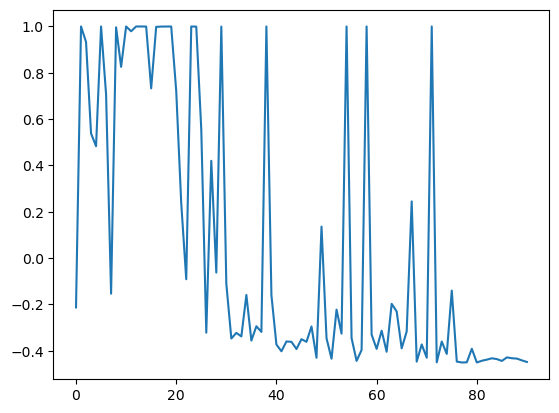

In [35]:
df.loss.plot()

## Obs vs pred of best fit

Best iteration: 78, NSE = 0.450


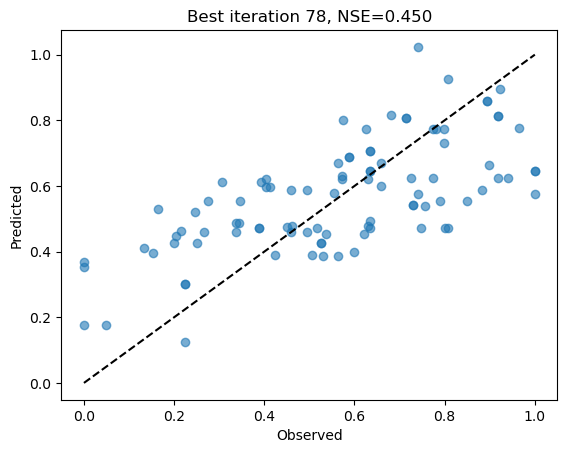

In [36]:

# Find the best iteration (minimum loss)
best_idx = df["loss"].idxmin()
best_row = df.loc[best_idx]
best_iter = best_row["iteration"]

print(f"Best iteration: {best_iter}, NSE = {-best_row['loss']:.3f}")

# Plot Obs vs Pred for the best iteration
plt.figure()
plt.scatter(best_row["obs"], best_row["pred"], alpha=0.6)
plt.plot(
    [best_row["obs"].min(), best_row["obs"].max()],
    [best_row["obs"].min(), best_row["obs"].max()],
    "k--"
)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title(f"Best iteration {best_iter}, NSE={-best_row['loss']:.3f}")
plt.show()


## Parameter space analysis

<Axes: >

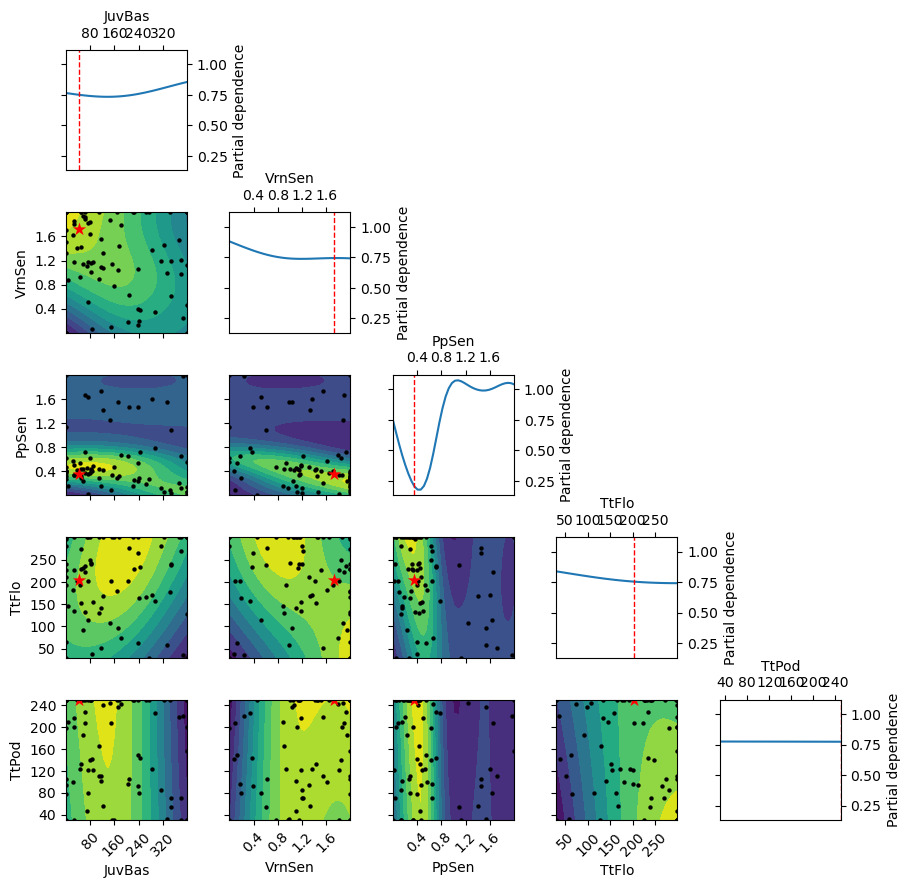

In [37]:
from skopt.plots import plot_objective
from skopt.utils import create_result

res = create_result(
    Xi=opt.Xi,
    yi=np.array(opt.yi),
    space=opt.space,
    specs=None,
    models=opt.models
)

plot_objective(res)

# Fit parameters for all cultivars

## Run optimiser for all cultivars

In [9]:
CULTIVAR_FILE_DICT.keys()

dict_keys(['Ace', 'Aldinga', 'Blitz', 'Bolt', 'Boomer', 'CIPAL0901', 'CIPAL1504', 'CIPAL1701', 'Commando', 'Ethiopian', 'Flash', 'Giant', 'Greenfield', 'HallmarkXT', 'Hurricane', 'Indianhead', 'Jumbo', 'Jumbo2', 'KelpieXT', 'Laird', 'Matilda', 'Nipper', 'Northfield', 'Nugget', 'Precoz', 'Syrian', 'Terrier'])

In [8]:
Fitting_Variables = ['Lentil.Phenology.StartBuddingDAS',
                     'Lentil.Phenology.StartFloweringDAS',
                     'Lentil.Phenology.StartPoddingDAS']

# ------------------------------------------------------------
# Parameter definitions
# ------------------------------------------------------------

param_config = [
    {
        "name": "[Phenology].JuvenileBase.FixedValue",
        "short_name": "JuvBas",
        "bounds": (0, 400),
        "step": 5,
        "initial": 108.8739
    },
    {
        "name": "[Phenology].VernSensitivity.FixedValue",
        "short_name": "VrnSen",
        "bounds": (0.0, 2.0),
        "step": 0.01,
        "initial": 0.8966
    },
    # {
    #     "name": "[Phenology].InductiveBase.FixedValue",
    #     "short_name": "IndBas",
    #     "bounds": (0.0, 400.0),
    #     "step": 5,
    #     "initial": 0
    # },
    {
        "name": "[Phenology].InductivePpSensitivity.FixedValue",
        "short_name": "PpSen",
        "bounds": (0.0, 2.0),
        "step": 0.01,
        "initial": 0.4307
    },
    {
        "name": "[Phenology].TtFlowerDevelopment.FixedValue",
        "short_name": "TtFlo",
        "bounds": (30.0, 300.0),
        "step": 5,
        "initial": 130
    },
    {
        "name": "[Phenology].TtPodDevelopment.FixedValue",
        "short_name": "TtPod",
        "bounds": (30, 250),
        "step": 5,
        "initial": 165
    }
]

fits = pd.DataFrame(columns = ["best_x", "best_y", "STORE", "opt"])
for c in CULTIVAR_FILE_DICT.keys():
    fits.loc[c,["best_x", "best_y", "STORE", "opt"]] = fit_cultivar(
                                                                        CultivarToFit = c,
                                                                        ObsPredTableName = "HarvestObsPred",
                                                                        fitting_variables=Fitting_Variables,
                                                                        param_config=param_config,
                                                                        random_sample_size=29,
                                                                        stage_size=10,
                                                                        max_stages=5,
                                                                        shrink_factor=0.05,
                                                                        local_steps=10
                                                                    )


=== Initial design: Ace ===
[001] JuvBas=110, VrnSen=0.90, PpSen=0.43, TtFlo=130, TtPod=165 | Loss = -0.7229 | n = 43 | 17.0s
[002] JuvBas=150, VrnSen=0.09, PpSen=0.09, TtFlo=200, TtPod=205 | Loss = 0.9683 | n = 43 | 18.0s
[003] JuvBas=380, VrnSen=1.22, PpSen=0.65, TtFlo=270, TtPod=70 | Loss = 0.9965 | n = 43 | 17.0s
[004] JuvBas=295, VrnSen=0.34, PpSen=0.78, TtFlo=155, TtPod=225 | Loss = 0.7737 | n = 43 | 18.0s
[005] JuvBas=240, VrnSen=0.13, PpSen=0.54, TtFlo=60, TtPod=150 | Loss = -0.4833 | n = 43 | 18.0s
[006] JuvBas=60, VrnSen=1.90, PpSen=1.66, TtFlo=225, TtPod=210 | Loss = 1.0000 | n = 43 | 18.0s
[007] JuvBas=60, VrnSen=1.93, PpSen=0.71, TtFlo=235, TtPod=225 | Loss = 0.9850 | n = 43 | 18.0s
[008] JuvBas=25, VrnSen=1.62, PpSen=0.56, TtFlo=180, TtPod=100 | Loss = 0.2560 | n = 43 | 18.0s
[009] JuvBas=345, VrnSen=0.61, PpSen=1.09, TtFlo=240, TtPod=55 | Loss = 0.9997 | n = 43 | 18.0s
[010] JuvBas=240, VrnSen=0.20, PpSen=0.28, TtFlo=165, TtPod=80 | Loss = -0.2838 | n = 43 | 18.0s
[011]

In [14]:
fits.to_pickle("secondSetOfFits")

## graphs

In [15]:
fits1 = pd.read_pickle("firtsSetOfFits")
fits2 = pd.read_pickle("secondSetOfFits")

### Evolution of fitting

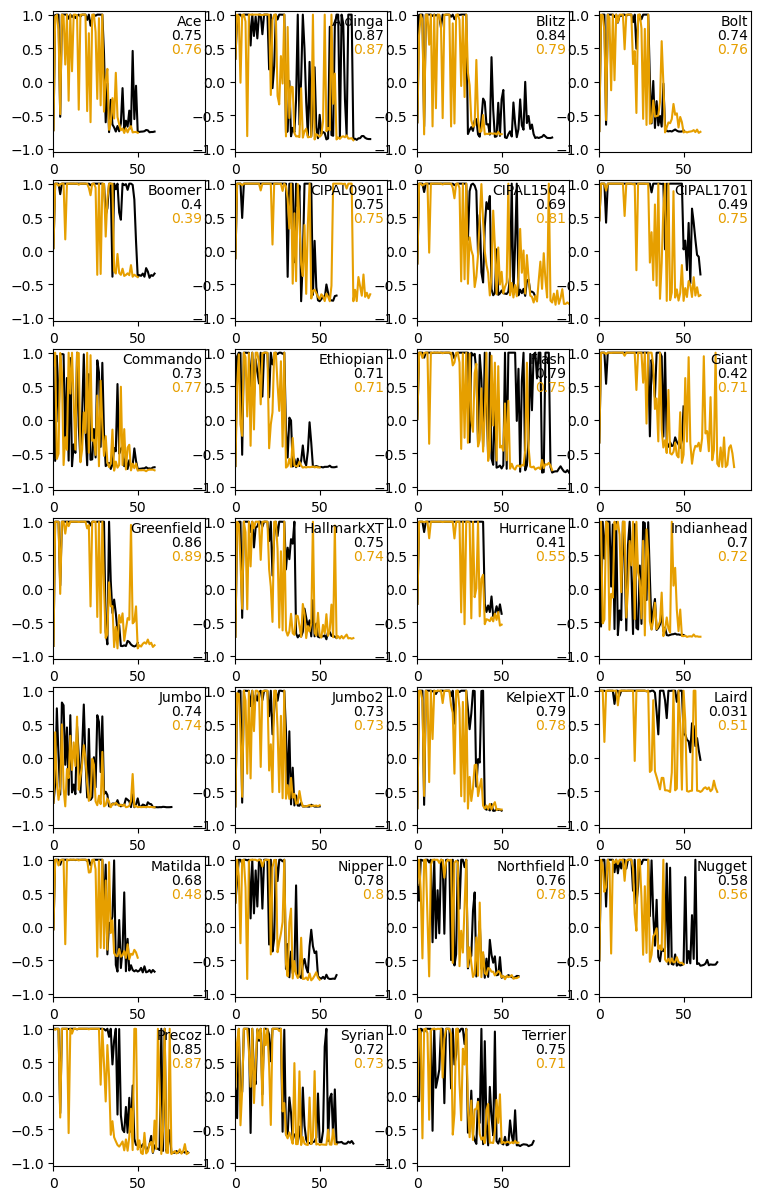

In [21]:
def graphFitEvolve(fits):
    graph = plt.figure(figsize=(9,15))
    pos = 1
    for c in CULTIVAR_FILE_DICT.keys():
        ax = graph.add_subplot(7,4,pos)
        fpos = 0
        for fit in fits:
            fcol = Colors[fpos+1]
            STORE = fit.loc[c,"STORE"]
            nse = -fit.loc[c,"best_y"]
            df = STORE.to_dataframe()
            df.loss.plot(color = fcol)
            plt.text(0.98,0.88-0.1*fpos,f"{nse:.2g}",horizontalalignment='right',
             verticalalignment='top', transform=ax.transAxes, color = fcol)
            fpos+=1
        plt.text(0.98,0.98,c,horizontalalignment='right',
                 verticalalignment='top', transform=ax.transAxes)

        plt.ylim(-1.05,1.05)
        plt.xlim(0,90)
        pos+=1

graphFitEvolve([fits1,fits2])

### obs vs pred scaled

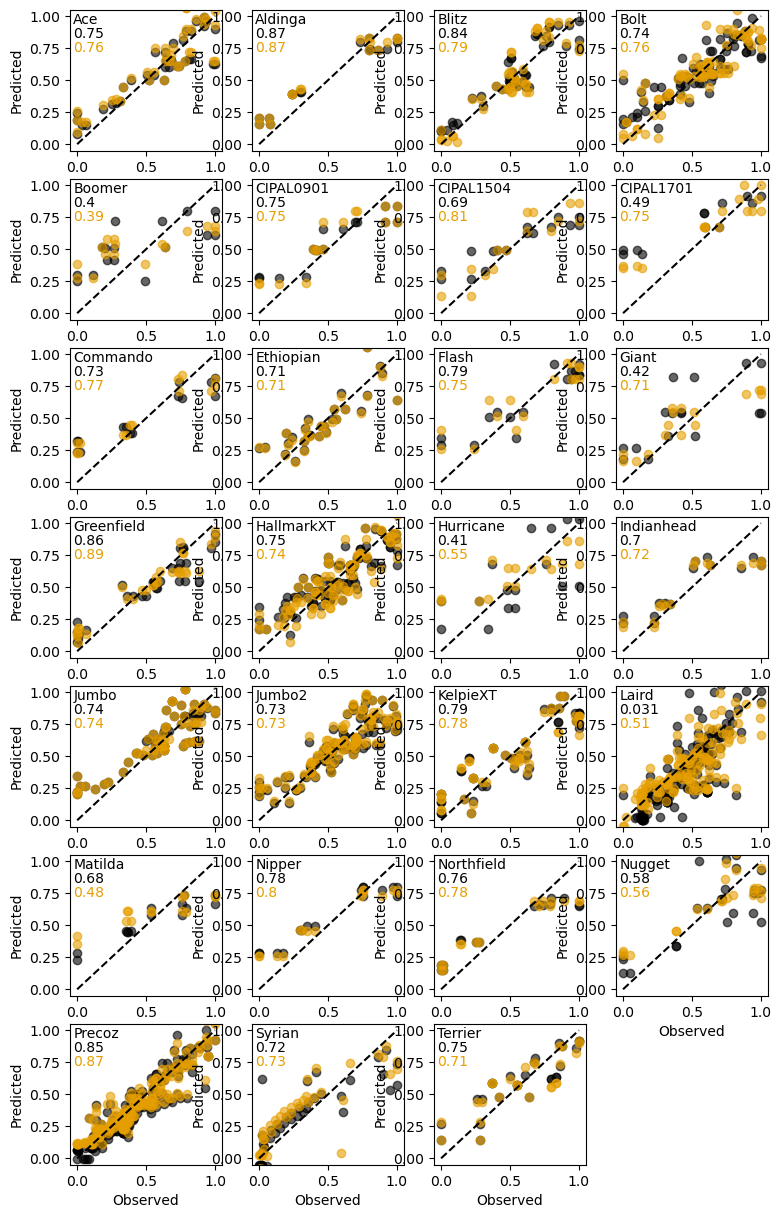

In [24]:
def graphObsPred(fits):
    graph = plt.figure(figsize=(9,15))
    pos = 1
    for c in CULTIVAR_FILE_DICT.keys():
        ax = graph.add_subplot(7,4,pos)
        fpos = 0
        for fit in fits:
            fcol = Colors[fpos +1]
            STORE = fit.loc[c,"STORE"]
            nse = -fit.loc[c,"best_y"]
            df = STORE.to_dataframe()
        
            # Find the best iteration (minimum loss)
            best_idx = df["loss"].idxmin()
            best_row = df.loc[best_idx]
            best_iter = best_row["iteration"]
                
            # Plot Obs vs Pred for the best iteration
            plt.plot(best_row["obs"], best_row["pred"], "o", alpha=0.6, color = fcol)
            plt.text(0.02,0.88-0.1*fpos,f"{nse:.2g}",horizontalalignment='left',
                    verticalalignment='top', transform=ax.transAxes, color = fcol)
            fpos+=1
        plt.plot([0,1],[0,1], "k--")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        #plt.title(f"Best iteration {best_iter}, NSE={-best_row['loss']:.3f}")
        #plt.show
        plt.text(0.02,0.98,c,horizontalalignment='left',
                 verticalalignment='top', transform=ax.transAxes)
        plt.ylim(-0.05,1.05)
        plt.xlim(-0.05,1.05)
        pos+=1

graphObsPred([fits1,fits2])

### parameter ranges

C:\Users\Cflhxb\AppData\Local\Temp\ipykernel_17652\1016083971.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


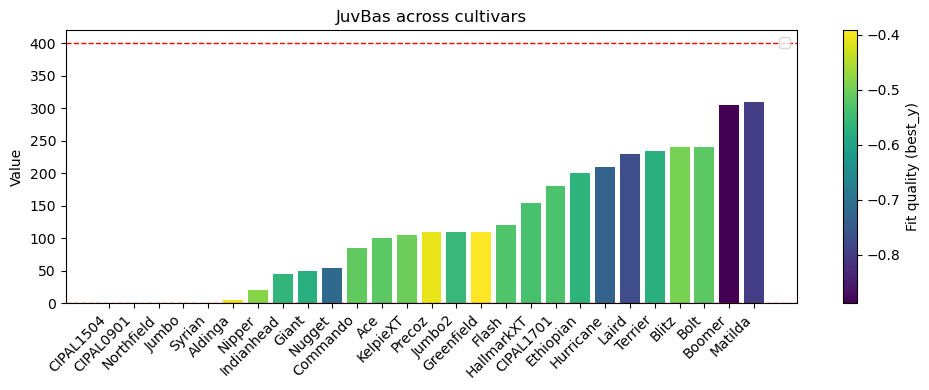

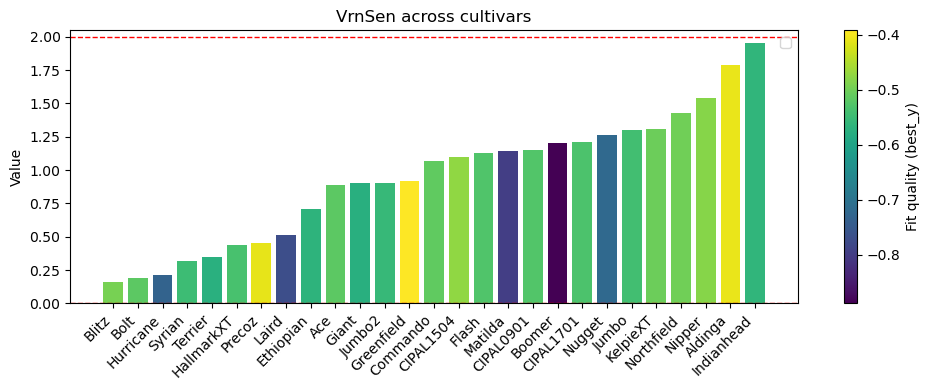

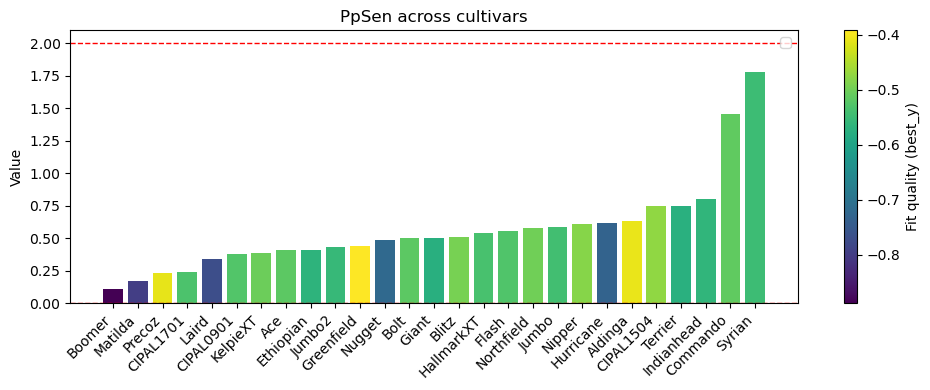

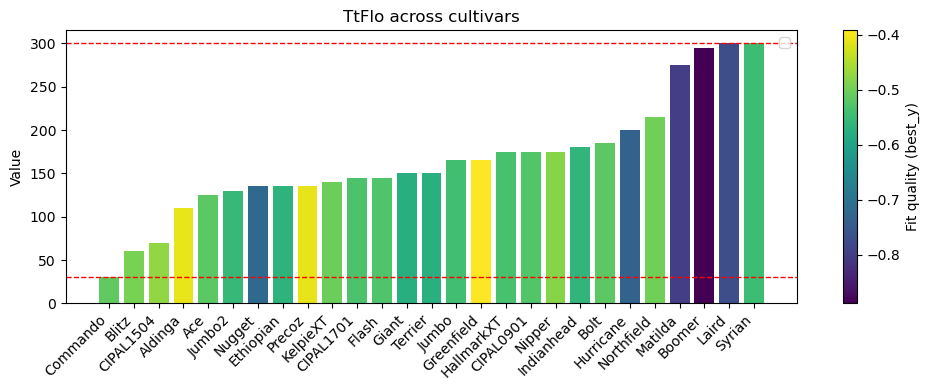

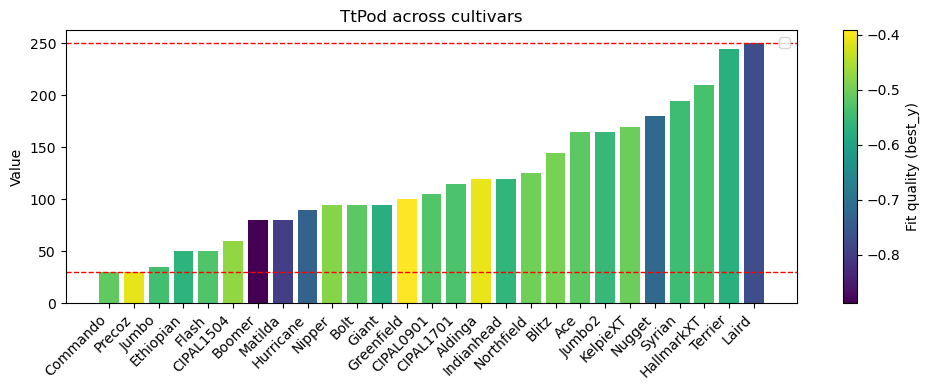

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize


def plot_parameter_bars(
    fits_df,
    param_config,
    sort=True,
    colour_by_loss=True,
    figsize=(10, 4)
):
    """
    Plot bar charts of fitted parameter values across cultivars with bounds.

    Parameters
    ----------
    fits_df : DataFrame
        Must contain 'best_x' and 'best_y', index = cultivars
    param_config : list of dict
        Defines parameter names, bounds, etc.
    sort : bool
        Sort cultivars by parameter value
    colour_by_loss : bool
        Colour bars by fit quality (best_y)
    """

    df = fits_df.copy()

    # -------------------------
    # Expand best_x
    # -------------------------
    param_cols = pd.DataFrame(df["best_x"].tolist(), index=df.index)

    param_names = [p["short_name"] for p in param_config]
    param_cols.columns = param_names

    df_params = pd.concat([df, param_cols], axis=1)

    # Ensure best_y is numeric
    df_params["best_y"] = pd.to_numeric(df_params["best_y"], errors="coerce")

    # -------------------------
    # Plot each parameter
    # -------------------------
    for i, p in enumerate(param_config):

        pname = p["short_name"]
        low, high = p["bounds"]

        plt.figure(figsize=figsize)

        plot_df = df_params.copy()

        if sort:
            plot_df = plot_df.sort_values(pname)

        values = plot_df[pname]

        ax = plt.gca()

        # -------------------------
        # Colour by loss
        # -------------------------
        if colour_by_loss:

            loss = plot_df["best_y"].fillna(plot_df["best_y"].max()).values.astype(float)
            
            vmin = np.min(loss)
            vmax = np.max(loss)
            
            if np.isclose(vmin, vmax):
                colors = ["steelblue"] * len(loss)
            else:
                norm = Normalize(vmin=vmin, vmax=vmax)
                normed = norm(loss)
            
                # ✅ invert so better fits (lower loss) = darker
                normed = 1 - normed
            
                colors = plt.cm.viridis(normed)
            
                sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
                sm.set_array([])
            
                ax = plt.gca()
                cbar = plt.colorbar(sm, ax=ax)
                cbar.set_label("Fit quality (best_y)")
            
            plt.bar(plot_df.index, values, color=colors)
        else:
            plt.bar(plot_df.index, values)

        # -------------------------
        # Bounds lines
        # -------------------------
        ax.axhline(low, linestyle="--", color="red", linewidth=1)
        ax.axhline(high, linestyle="--", color="red", linewidth=1)

        # -------------------------
        # Titles and formatting
        # -------------------------
        ax.set_title(f"{pname} across cultivars")
        ax.set_ylabel("Value")

        plt.xticks(rotation=45, ha="right")

        # Only show legend once (optional)
        ax.legend(loc="upper right")

        plt.tight_layout()
        plt.show()


plot_parameter_bars(fits, param_config)

### fit surfaces

<Axes: >

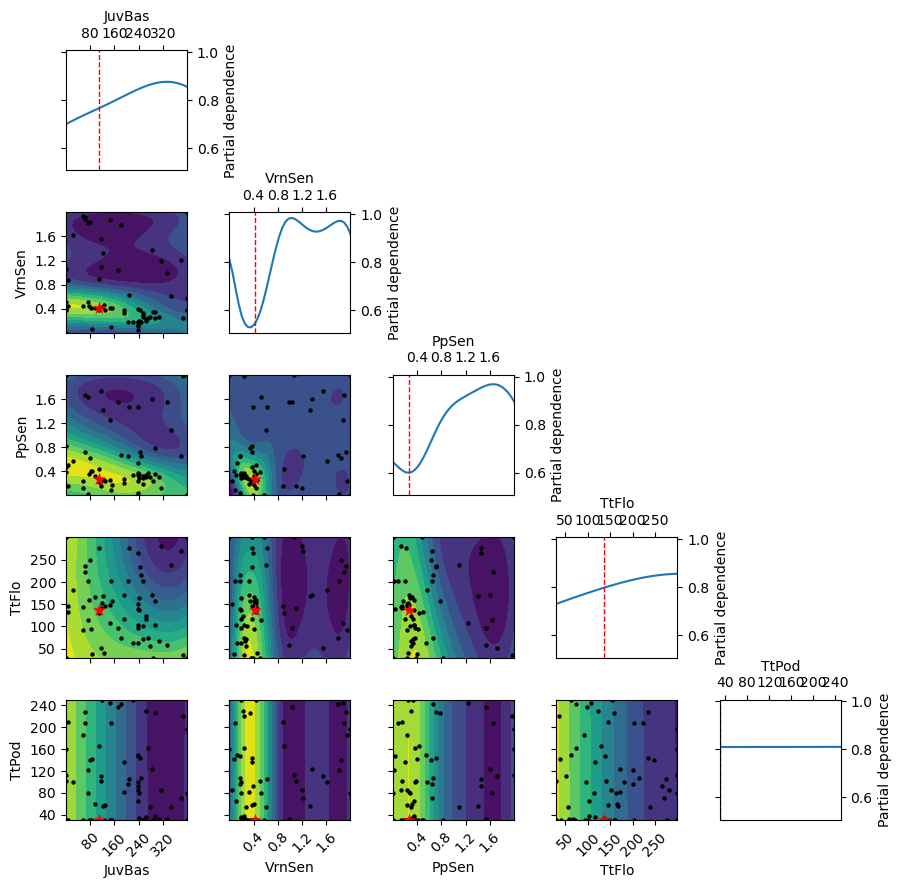

In [12]:
from skopt.plots import plot_objective
from skopt.utils import create_result
opt = fits.loc["Precoz","opt"]
res = create_result(
    Xi=opt.Xi,
    yi=np.array(opt.yi),
    space=opt.space,
    specs=None,
    models=opt.models
)

plot_objective(res)

## Inject fitted parameters to lentil.json

In [31]:
import json

def update_apsimx_cultivars(
    crop_json_path,
    fits_df,
    param_config
):
    """
    Update cultivar parameter commands in an APSIM .apsimx file.

    Parameters
    ----------
    crop_json_path : str
        Path to crop.json config file
    fits_df : DataFrame
        Must contain index = cultivar name, and column 'best_x'
    param_config : list of dict
        Defines parameter "name" field
    """

    # -------------------------
    # Load JSON
    # -------------------------
    with open(crop_json_path, "r") as f:
        data = json.load(f)

    # -------------------------
    # Helper: find Cultivars node
    # -------------------------
    def find_cultivars_node(node):
        if isinstance(node, dict):
            if node.get("Name") == "Cultivars":
                return node
            for child in node.get("Children", []):
                result = find_cultivars_node(child)
                if result:
                    return result
        elif isinstance(node, list):
            for item in node:
                result = find_cultivars_node(item)
                if result:
                    return result
        return None

    cultivars_node = find_cultivars_node(data)

    if cultivars_node is None:
        raise RuntimeError("Could not find 'Cultivars' node in APSIM file")

    # -------------------------
    # Update each cultivar
    # -------------------------
    for cultivar_node in cultivars_node.get("Children", []):

        cultivar_name = cultivar_node.get("Name")

        if cultivar_name not in fits_df.index:
            continue  # skip cultivars without fitted values

        best_x = fits_df.loc[cultivar_name, "best_x"]

        # -------------------------
        # Build new command list
        # -------------------------
        commands = []

        for val, p in zip(best_x, param_config):

            # optional: quantise again for safety

            step = p.get("step")
            
            val_str = format_value(val, step)
            
            cmd = f"{p['name']} = {val_str}"

            commands.append(cmd)

        # -------------------------
        # Replace Command block
        # -------------------------
        cultivar_node["Command"] = commands

        print(f"Updated cultivar: {cultivar_name}")

    # -------------------------
    # Save new file
    # -------------------------
    with open(crop_json_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"\nUpdated APSIM file written to:\n{crop_json_path}")

In [32]:
update_apsimx_cultivars(
    crop_json_path="C:\GitHubRepos\ApsimX\Models\Resources\Lentil.json",
    fits_df=fits,
    param_config=param_config
)


Updated cultivar: Ace
Updated cultivar: Aldinga
Updated cultivar: Blitz
Updated cultivar: Bolt
Updated cultivar: Boomer
Updated cultivar: CIPAL0901
Updated cultivar: CIPAL1504
Updated cultivar: CIPAL1701
Updated cultivar: Commando
Updated cultivar: Flash
Updated cultivar: Greenfield
Updated cultivar: Giant
Updated cultivar: HallmarkXT
Updated cultivar: Hurricane
Updated cultivar: Indianhead
Updated cultivar: Jumbo
Updated cultivar: Jumbo2
Updated cultivar: KelpieXT
Updated cultivar: Matilda
Updated cultivar: Nipper
Updated cultivar: Northfield
Updated cultivar: Nugget
Updated cultivar: Terrier
Updated cultivar: Precoz
Updated cultivar: Laird
Updated cultivar: Syrian
Updated cultivar: Ethiopian

Updated APSIM file written to:
C:\GitHubRepos\ApsimX\Models\Resources\Lentil.json
